In [2]:
# Read Hazards and Impacts (annual input data)
import os
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
def read_data(agg_type):
    agg_type=str(agg_type)
    # Get the current file directory (where the notebook is running)
    current_dir = os.getcwd()
    # Navigate to the root of the repository (adjust based on your directory structure)
    repo_root = os.path.abspath(os.path.join(current_dir, '..'))  # Or adjust the number of ".." as needed
    # Define the paths dynamically
    hazard_folder=  os.path.join(repo_root, "Hazard data")
    impact_folder= os.path.join(repo_root, "Impact data")
    hazard=pd.read_csv(os.path.join(hazard_folder, 'Merged_hazards_noconv_'+agg_type+'.csv'))
    impact=pd.read_csv(os.path.join(impact_folder, 'Merged_impacts_anomalies_nofilter.csv'))
    hazard['Time']=hazard['Time'].astype(int) # yearly data
    impact['Time']=impact['Time'].astype(int) # yearly data
    impact = impact.drop('Unnamed: 0', axis=1)
    #impact[impact['Value']==0]=np.nan
    impact['Type']='impact'
    hazard['Type']='hazard'
    data=hazard.copy()
    data = pd.concat([data, impact], ignore_index=True)
    data=data[data['Time']>=2005] # Restrict all dataset to study period
    data=data[data['Time']<=2022]
    return data


In [3]:
# Import functions for anomaly calculation
import numpy as np
#from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from shapely.geometry import Polygon
from cartopy.io import shapereader
import cartopy.io.img_tiles as cimgt
import cartopy.crs as ccrs
import geopandas
import pandas as pd
import geopandas as gpd
from scipy.interpolate import griddata
import matplotlib.colors as colors
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import matplotlib.ticker as ticker
from rasterstats import zonal_stats
import rasterio

def anomaly2(t, y, impact_variable, degree):
    # Fit polynomial regression
    tn = mdates.date2num(t)
    X = np.array(tn).reshape(-1, 1)
    y = np.array(y)

    polynomial_features = PolynomialFeatures(degree=degree)
    X_poly = polynomial_features.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    # Expected variable using polynomial regression
    y_trend = model.predict(X_poly)

    # Calculate annual percentages of anomaly
    y_anom = (y-y_trend)/abs(y_trend)*100
    return y_anom

def plot_anomaly2(t, y, impact_variable, degree):
    # Fit polynomial regression
    tn = mdates.date2num(t)
    X = np.array(tn).reshape(-1, 1)
    y = np.array(y)

    polynomial_features = PolynomialFeatures(degree=degree)
    X_poly = polynomial_features.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    # Expected variable using polynomial regression
    y_trend = model.predict(X_poly)

    # Calculate annual percentages of anomaly
    y_anom = (y-y_trend)/abs(y_trend)*100

    # Plot the results
    plt.plot(pd.to_datetime(t, format='%Y'), y, linestyle='-', color='black', label='Original Data')
    plt.plot(pd.to_datetime(t, format='%Y'), y_trend, linestyle='--', color='blue', label='Polynomial Regression Trend')
    plt.xlabel('Time')
    plt.ylabel(impact_variable)
    plt.legend()
    plt.show()

plt.rcdefaults()
resolution = '50m'
category = 'cultural'
name = 'admin_0_countries'

shpfilename = shapereader.natural_earth(resolution, category, name)
df = gpd.read_file(shpfilename)

# Define the file paths for the shapefiles
current_dir = os.getcwd()
# Navigate to the root of the repository (adjust based on your directory structure)
repo_root = os.path.abspath(os.path.join(current_dir, '..')) 
# Define the paths dynamically
shapefiles_path = os.path.join(repo_root, "Hazard data", "shapefiles")
kommun_file = os.path.join(shapefiles_path,'Kommun_Sweref99TM_region.shp')
# Read the shapefiles using geopandas
kommun_shapefile = gpd.read_file(kommun_file)
kommun_shapefile = kommun_shapefile.to_crs("EPSG:4326")

def plot_map(gdf, col, title, label, lower_bound, upper_bound, vcenter, cmap_type, save, filename):
    st_proj = ccrs.PlateCarree()  # projection used by Stamen images
    ll_proj = ccrs.PlateCarree()  # CRS for raw long/lat
    
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': st_proj})
    gdf[col]=pd.to_numeric(gdf[col])
    # add geometries to the axes
    #gdf[col] = gdf[col].fillna(0)
    im0 = kommun_shapefile.plot(edgecolor='grey', facecolor='white', linewidth=0.5, legend=False, ax=ax)
    im = gdf.plot(column=col, cmap=cmap_type, 
             vmin=lower_bound, vmax=upper_bound,
             legend=False, ax=ax, 
             legend_kwds={'label': label, 'orientation': 'horizontal'})
    ax.set_title(title, fontsize=14)
    ax.set_extent([11.008164910000085, 24.263413534000115, 55.242678127000055, 69.13635569300011], crs=ll_proj)  # Set your desired extent
    ax.set_aspect('equal', adjustable='box')
    # Specify the shrink parameter to adjust the width of the colorbar
    cbar = plt.colorbar(im.get_children()[1], ax=ax, extend='both', orientation='horizontal', shrink=0.556, pad=0.01)
    # Add a label to the colorbar
    cbar.set_label(label, fontsize=12)
    if save == 'yes':
        fig.savefig(f'figures/{filename}.png', dpi=300, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

In [3]:
# Precalculate all anomalies
data_imp_anom=pd.DataFrame()
# Get the current file directory (where the notebook is running)
current_dir = os.getcwd()
# Navigate to the root of the repository (adjust based on your directory structure)
repo_root = os.path.abspath(os.path.join(current_dir, '..'))  # Or adjust the number of ".." as needed
# Define the paths dynamically
impact_folder= os.path.join(repo_root, "Impact data")
impact=pd.read_csv(os.path.join(impact_folder, 'Merged_impacts.csv'))
trends=['Linear']
impact=impact[impact['Time']>=2005] # Only most recent years (only for all yearly data)
# Pre-calculate anomaly of supply variables (Independent of climate index data)
municipalities= impact['Municipality'].dropna().unique()
impact_variables= ['crop_yield_total', 'discharge', 'hydro_prod']
for impact_variable in impact_variables:
    data_imp= impact[impact['Variable']==impact_variable]
    data_imp['Value'] = pd.to_numeric(data_imp['Value'])
    print(impact_variable)
    for trend in trends:
        print(trend)
        for municipality in municipalities:
            data_imp_mun= data_imp[data_imp['Municipality']==municipality]
            data_imp_mun= data_imp_mun.sort_values('Time', ascending=True)
            data_imp_mun[data_imp_mun['Value']==0]=np.nan # remove data with zeroes (hydro prod for example)
            data_imp_mun=data_imp_mun.dropna(subset='Value')
            y = pd.to_numeric(data_imp_mun['Value'], errors='coerce') # supply variable
            y = y.values
            t = pd.to_numeric(data_imp_mun.Time.values, errors='coerce')
            if len(t)>3:
                if trend=='Linear':
                    y_anom = anomaly2(t, y, impact_variable, 1) # first degree polynomial
            else:
                y_anom=[np.nan for x in t]
            data_imp_mun['Anomalies']=y_anom
            data_imp_mun['Trend']=trend
            data_imp_anom = pd.concat([data_imp_anom, data_imp_mun], ignore_index=True)

crop_yield_total
Linear
discharge
Linear
hydro_prod
Linear


In [ ]:
# Plot distribution of all anomalies
trends=['Linear']
filtered_final=pd.DataFrame()
for trend in trends:
    data_check=data_imp_anom[data_imp_anom['Trend']==trend]
    #data_check[data_check['Anomalies']==0]=np.nan
    data_check=data_check.dropna(subset='Anomalies')
    # Remove outliers
    Q1 = data_check['Anomalies'].quantile(0.25)
    Q3 = data_check['Anomalies'].quantile(0.75)
    IQR = Q3 - Q1
    # Calculate lower and upper bounds
    lower_bound = Q1 - 5 * IQR
    upper_bound = Q3 + 5 * IQR
    # Filter out outliers
    data_check = data_check[(data_check['Anomalies'] >= lower_bound) & (data_check['Anomalies'] <= upper_bound)]
    fig, ax = plt.subplots()
    ax.hist(data_check['Anomalies'], bins=15)
    ax.set_title(trend)
    #ax.set_xlim([-150, 150])
    filtered_final = pd.concat([filtered_final, data_check], ignore_index=True)

In [ ]:
# Save anomalies without filtering
data_imp_anom.to_csv(os.path.join(impact_folder, 'Merged_impacts_anomalies_nofilter.csv'))

In [32]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import calendar

def plot_combined(trend, t, y, impvar_name, var_unit, x, y_anom, x_smooth, y_smooth_pred, params,
                  hazvar_name, municipality, rmse, p, r_squared, agg_type, dw_stat, bp_pvalue,
                  degrees_to_test=None, degree_cv_rmses=None, best_degree=None):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import numpy as np
    import pandas as pd
    from sklearn.linear_model import LinearRegression
    from sklearn.preprocessing import PolynomialFeatures
    import calendar

    def format_model_string(params, best_degree):
        if params is None or any(np.isnan(p) for p in params):
            return "Model: Not available"
        parts = []
        for i in range(best_degree, -1, -1):
            param_index = best_degree - i
            coeff = params[param_index]
            sign = ""
            if len(parts) > 0:
                sign = "+ " if coeff >= 0 else "- "
            elif coeff < 0:
                sign = "- "
            abs_coeff = abs(coeff)
            var_part = f"I^{i}" if i > 1 else "I" if i == 1 else ""
            if abs_coeff == 1.0 and i > 0:
                parts.append(f"{sign}{var_part}")
            else:
                parts.append(f"{sign}{abs_coeff:.2f}{var_part}")
        model_str = ' '.join(parts).strip()
        if model_str.startswith('+ '):
            model_str = model_str[2:]
        return f"y = {model_str}"

    # --- Plotting Setup ---
    SIZE_DEFAULT = 15
    SIZE_LARGE = 18
    plt.rc("font", family="Arial", weight="normal", size=SIZE_DEFAULT)
    plt.rc("axes", titlesize=SIZE_LARGE, labelsize=SIZE_LARGE)
    plt.rc("xtick", labelsize=SIZE_DEFAULT)
    plt.rc("ytick", labelsize=SIZE_DEFAULT)

    ncols = 3
    fig, axes = plt.subplots(1, ncols, figsize=(18, 5), dpi=300)
    ax1, ax3, ax2 = axes  # Inverted order: ax3 is now the middle plot
    colors = ["#2B2F42", "#8D99AE", "#EF233C", "#A9E5BB", "#64B5F6"]

    # --- Plot 1: Detrending ---
    y_trend = np.full_like(y, np.nan, dtype=float)
    t_datetime = pd.to_datetime(t, errors='coerce')
    valid_data_mask = ~np.isnan(y) & ~pd.isnull(t_datetime)
    if np.sum(valid_data_mask) > 1 and trend == 'Linear':
        tn = mdates.date2num(t_datetime[valid_data_mask])
        X_lin = tn.reshape(-1, 1)
        y_lin = y[valid_data_mask]
        model_lin = LinearRegression().fit(X_lin, y_lin)
        y_trend_valid = model_lin.predict(X_lin)
        y_trend_plot = np.full_like(y, np.nan, dtype=float)
        y_trend_plot[valid_data_mask] = y_trend_valid
        ax1.plot(t_datetime, y_trend_plot, linestyle='--', color='blue', label=f'{trend} Trend', linewidth=2)
    ax1.scatter(t_datetime, y, color='black', label='Original Data', s=50)
    ax1.spines["right"].set_visible(False)
    ax1.spines["top"].set_visible(False)
    ax1.set_xlabel('Time')
    ax1.set_ylabel(f'{impvar_name} ({var_unit})')
    ax1.set_title(f'{municipality} Municipality')
    ax1.legend()
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax1.grid(False)

    # --- Plot 2 (now last subplot): Anomaly Function ---
    ax2.scatter(x, y_anom, color='black', label='Observed Anomalies', s=50)
    model_str = format_model_string(params, best_degree)
    ax2.plot(x_smooth, y_smooth_pred, color=colors[2], label=model_str, linewidth=2)
    ax2.spines["right"].set_visible(False)
    ax2.spines["top"].set_visible(False)

    month_text = f"{calendar.month_name[agg_type]} months"
    ax2.set_xlabel(f'Yearly maxima {hazvar_name} of {month_text}')
    ax2.set_ylabel(f'{impvar_name} Anomaly (%)')
    ax2.set_ylim([-130, 130])
    ax2.set_title('Impact Modelling')

    r_squared_str = f'{r_squared:.2f}' if r_squared is not None and not np.isnan(r_squared) else 'N/A'
    rmse_str = f'{rmse:.2f}%' if rmse is not None and not np.isnan(rmse) else 'N/A'
    p_str = f'{p:.5f}' if p is not None and not np.isnan(p) else 'N/A'
    dw_result = "No autocorrelation" if dw_stat is not None and not np.isnan(dw_stat) and 1.5 <= dw_stat <= 2.5 else "Autocorrelation detected"
    bp_result = "No heteroskedasticity" if bp_pvalue is not None and not np.isnan(bp_pvalue) and bp_pvalue > 0.05 else "Heteroskedasticity detected"
    dw_stat_str = f'{dw_stat:.2f}' if dw_stat is not None and not np.isnan(dw_stat) else 'N/A'
    bp_pvalue_str = f'{bp_pvalue:.3f}' if bp_pvalue is not None and not np.isnan(bp_pvalue) else 'N/A'

    textstr = (f'$R^2_{{CV}}$: {r_squared_str}, Cross-Validation RMSE (%): {rmse_str}\n'
               f'p: {p_str}\n'
               f'Durbin–Watson: {dw_stat_str} ({dw_result})\n'
               f'Breusch–Pagan p: {bp_pvalue_str} ({bp_result})')
    props = dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.5)
    ax2.text(0.05, 0.95, textstr, transform=ax2.transAxes, fontsize=SIZE_DEFAULT,
             verticalalignment='top', bbox=props)
    ax2.legend(loc='lower right')
    ax2.grid(False)

    # --- Plot 3 (now middle plot): Degree Selection ---
    if degrees_to_test and degree_cv_rmses:
        valid_degrees = [deg for deg, rmse_val in zip(degrees_to_test, degree_cv_rmses) if rmse_val < np.inf]
        valid_rmses = [rmse_val for rmse_val in degree_cv_rmses if rmse_val < np.inf]
        if len(valid_degrees) > 1:
            ax3.plot(valid_degrees, valid_rmses, label='CV RMSE', marker='o')
            ax3.set_xticks([1, 2, 3, 4]) 
            if best_degree is not None and not np.isnan(best_degree):
                ax3.axvline(x=best_degree, color='red', linestyle='--', label=f'Best Degree: {int(best_degree)}')
            ax3.set_title('Polynomial Degree Selection')
            ax3.set_xlabel('Polynomial Degree')
            ax3.set_ylabel('Cross-Validation RMSE (%)')
            ax3.legend()
            ax3.grid(False) 
        else:
            ax3.text(0.5, 0.5, 'Not enough valid models\nto compare degrees.', ha='center', va='center', transform=ax3.transAxes)
            ax3.axis('off')
    else:
        ax3.text(0.5, 0.5, 'Degree selection data\nnot available.', ha='center', va='center', transform=ax3.transAxes)
        ax3.axis('off')

    plt.tight_layout(pad=1.5)
    plt.savefig(f'fig_{municipality}_{hazvar_name}_{trend}.pdf', dpi=300)
    plt.savefig(f'fig_{municipality}_{hazvar_name}_{trend}.eps', dpi=300)
    plt.show()

In [18]:
# Model fitting per municipality 
from tqdm import tqdm_notebook as tqdm
import warnings
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import curve_fit
from scipy.stats import f
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.model_selection import KFold
import statsmodels.api as sm
import sys

impact_info=pd.read_excel('Variable List.xlsx','Impact')
hazard_info=pd.read_excel('Variable List.xlsx', 'Hazard')

# Ignore all warnings
warnings.filterwarnings('ignore')
from scipy.stats import pearsonr, linregress
import numpy as np
alpha=0.0 # R-squared threshold
c_alpha=1 # plotting alpha for scatter plots
threshold=-9999 # hazard index minimum threshold
agg_type=1 # monthly aggregation
data=read_data(agg_type)
#data = data.drop(columns=['Unnamed: 0.1'])
municipalities= data['Municipality'].unique()
# Set the parameter bounds
lower_bounds = [-10, -10, -10, -10]
upper_bounds = [10, 10, 10, 10]


def correlations(data, impact_variable, hazard_variable, threshold, trend, agg_type, impact_info, hazard_info, lower_bounds, upper_bounds): # Added more params
    all_count_df=pd.DataFrame()
    all_saved_data= pd.DataFrame()
    print(impact_variable)
    
    mun_total=impact_info[impact_info['var']==impact_variable]['Municipalities Covered'].values[0]
    var_unit=impact_info[impact_info['var']==impact_variable]['Converted Unit'].values[0]
    impvar_name=impact_info[impact_info['var']==impact_variable]['Variable Name'].values[0]
    try:
        hazvar_name=hazard_info[hazard_info['var']==hazard_variable]['Variable Name'].values[0]
    except:
        hazvar_name=hazard_variable

    print(hazard_variable)
    data_haz = data[data['Variable']==hazard_variable].copy() # Use .copy() to avoid SettingWithCopyWarning
    data_haz = data_haz.drop(columns=['Anomalies', 'Trend'], errors='ignore') # errors='ignore' if columns might not exist
    data_haz['Value'] = pd.to_numeric(data_haz['Value'], errors='coerce')
    
    if hazard_variable=='SPEI12': # Assuming threshold is defined globally or passed
        data_haz.loc[data_haz['Value'] > threshold, 'Value'] = np.nan
    else:    
        data_haz.loc[data_haz['Value'] < threshold, 'Value'] = np.nan
    data_haz = data_haz.replace([-np.inf, np.inf], pd.NA).dropna(subset=['Value'])
    
    data_imp = data[data['Variable']==impact_variable].copy() # Use .copy()
    data_imp['Value'] = pd.to_numeric(data_imp['Value'], errors='coerce')
    municipalities = data_imp['Municipality'].dropna().unique()
    data_imp = data_imp[data_imp['Trend']==trend]
    data_pair = data_imp.merge(data_haz, on=['Time','Municipality'], suffixes=('_imp', '_haz')) # Use suffixes

    corrs=[]
    pvalues_full_model=[] 
    all_obs=[]
    all_pre=[]
    a_coeff, b_coeff, c_coeff, d_coeff, e_coeff = [], [], [], [], []
    muns=[]
    all_cv_rmses_list = [] # To store CV_RMSE for each municipality
    best_degrees = [] # To store the best polynomial degree for each municipality

    count_sig=0
    
    # Define polynomial model functions for different degrees
    def poly_model_degree1(x, a, b):
        return a * x + b
    
    def poly_model_degree2(x, a, b, c):
        return a * x**2 + b * x + c
    
    def poly_model_degree3(x, a, b, c, d):
        return a * x**3 + b * x**2 + c * x + d
    
    def poly_model_degree4(x, a, b, c, d, e):
        return a * x**4 + b * x**3 + c * x**2 + d * x + e
    
    # Dictionary to map degrees to functions and bounds
    poly_models = {
        1: {
            'func': poly_model_degree1,
            'bounds': ([-10, -10], [10, 10])
        },
        2: {
            'func': poly_model_degree2,
            'bounds': ([-10, -10, -10], [10, 10, 10])
        },
        3: {
            'func': poly_model_degree3,
            'bounds': ([-10, -10, -10, -10], [10, 10, 10, 10])
        },
        4: {
            'func': poly_model_degree4,
            'bounds': ([-10, -10, -10, -10, -10], [10, 10, 10, 10, 10])
        }
    }
    
    with tqdm(total=(len(municipalities))) as pbar:
        for municipality in municipalities:
            saved_data_mun = pd.DataFrame() # For storing detailed time series data per municipality
            data_pair_mun = data_pair[data_pair['Municipality']==municipality].sort_values('Time', ascending=True)
            
            y_impact_values = pd.to_numeric(data_pair_mun['Value_imp'], errors='coerce').copy()
            y_impact_values[y_impact_values==0] = np.nan # remove data with zeroes
            x_hazard_values = pd.to_numeric(data_pair_mun['Value_haz'], errors='coerce')
            y_anom_observed = pd.to_numeric(data_pair_mun['Anomalies'], errors='coerce') # Anomalies of impact variable
            
            time_values = data_pair_mun['Time'].values
            
            # Filter for valid pairs for regression
            valid_indices = (~np.isnan(x_hazard_values)) & (~np.isinf(x_hazard_values)) & \
                            (~np.isnan(y_anom_observed)) & (~np.isinf(y_anom_observed)) & \
                            (~np.isnan(y_impact_values)) # Also ensure original y_impact is valid if used
            
            x_reg = x_hazard_values[valid_indices].values
            y_anom_reg = y_anom_observed[valid_indices].values
            t_reg = time_values[valid_indices]
            y_impact_reg = y_impact_values[valid_indices].values

            n_samples = len(x_reg)

            # Initialize metrics for this municipality
            current_cv_r_squared = np.nan
            current_cv_rmse = np.nan
            current_p_value_full = np.nan
            current_a, current_b, current_c, current_d = np.nan, np.nan, np.nan, np.nan
            y_anom_pred_for_saving = np.full_like(y_anom_reg, np.nan, dtype=float)
            best_degree = np.nan

            if n_samples >= 4: # Min data for fitting polynomial
                # --- Test different polynomial degrees ---
                degrees_to_test = [1, 2, 3, 4]
                degree_cv_rmses = []
                degree_results = {}
                
                for degree in degrees_to_test:
                    if n_samples >= degree + 1:  # Need at least degree+1 points for polynomial of given degree
                        try:
                            # Test this degree with cross-validation
                            if n_samples >= 10:  # Use 5-fold CV if enough samples
                                kf = KFold(n_splits=5, shuffle=True, random_state=42)
                                kfold_y_true = []
                                kfold_y_pred = []
                                cv_successful = True
                                
                                for train_idx, test_idx in kf.split(x_reg):
                                    x_train_fold, x_test_fold = x_reg[train_idx], x_reg[test_idx]
                                    y_train_fold, y_test_fold_true = y_anom_reg[train_idx], y_anom_reg[test_idx]
                                    
                                    try:
                                        params_fold, _ = curve_fit(poly_models[degree]['func'], x_train_fold, y_train_fold, 
                                                                 bounds=poly_models[degree]['bounds'])
                                        y_pred_fold = poly_models[degree]['func'](x_test_fold, *params_fold)
                                        kfold_y_true.extend(y_test_fold_true)
                                        kfold_y_pred.extend(y_pred_fold)
                                    except RuntimeError:
                                        cv_successful = False
                                        break
                                
                                if cv_successful and len(kfold_y_true) == n_samples:
                                    cv_rmse = np.sqrt(mean_squared_error(kfold_y_true, kfold_y_pred))
                                    degree_cv_rmses.append(cv_rmse)
                                    degree_results[degree] = {
                                        'cv_rmse': cv_rmse,
                                        'y_true': np.array(kfold_y_true),
                                        'y_pred': np.array(kfold_y_pred)
                                    }
                                else:
                                    degree_cv_rmses.append(np.inf)
                            else:
                                # For small samples, just fit and evaluate on full data
                                try:
                                    params_full, _ = curve_fit(poly_models[degree]['func'], x_reg, y_anom_reg, 
                                                             bounds=poly_models[degree]['bounds'])
                                    y_pred_full = poly_models[degree]['func'](x_reg, *params_full)
                                    cv_rmse = np.sqrt(mean_squared_error(y_anom_reg, y_pred_full))
                                    degree_cv_rmses.append(cv_rmse)
                                    degree_results[degree] = {
                                        'cv_rmse': cv_rmse,
                                        'y_true': y_anom_reg,
                                        'y_pred': y_pred_full
                                    }
                                except RuntimeError:
                                    degree_cv_rmses.append(np.inf)
                        except:
                            degree_cv_rmses.append(np.inf)
                    else:
                        degree_cv_rmses.append(np.inf)
                
                # Select best degree (lowest CV RMSE)
                if len(degree_cv_rmses) > 0 and min(degree_cv_rmses) < np.inf:
                    best_idx = np.argmin(degree_cv_rmses)
                    best_degree = degrees_to_test[best_idx]
                    
                    # Use the best degree for final fitting
                    try:
                        # Fit full model with best degree
                        params_full, _ = curve_fit(poly_models[best_degree]['func'], x_reg, y_anom_reg, 
                                                 bounds=poly_models[best_degree]['bounds'])
                        y_pred_full_model = poly_models[best_degree]['func'](x_reg, *params_full)
                        residuals_full = y_anom_reg - y_pred_full_model
                        
                        # Store coefficients (pad with NaN if degree < 4)
                        if best_degree == 1:
                            current_a, current_b, current_c, current_d, current_e = np.nan, np.nan, params_full[0], params_full[1], np.nan
                        elif best_degree == 2:
                            current_a, current_b, current_c, current_d, current_e = np.nan, params_full[0], params_full[1], params_full[2], np.nan
                        elif best_degree == 3:
                            current_a, current_b, current_c, current_d, current_e = params_full[0], params_full[1], params_full[2], params_full[3], np.nan
                        elif best_degree == 4:
                            current_a, current_b, current_c, current_d, current_e = params_full
                        
                        # Calculate p-value for full model
                        k_params = len(params_full)
                        if n_samples > k_params:
                            y_mean_full = np.mean(y_anom_reg)
                            SSR_full = np.sum((y_pred_full_model - y_mean_full)**2)
                            SSE_full = np.sum(residuals_full**2)
                            df_model = k_params - 1
                            df_error = n_samples - k_params
                            if df_model > 0 and df_error > 0 and SSE_full > 1e-9:
                                F_stat_full = (SSR_full / df_model) / (SSE_full / df_error)
                                current_p_value_full = 1 - f.cdf(F_stat_full, dfn=df_model, dfd=df_error)
                        
                        # Diagnostic tests
                        dw_stat = durbin_watson(residuals_full)
                        X_bp_full = np.column_stack([x_reg**i for i in range(best_degree, 0, -1)] + [np.ones_like(x_reg)])
                        if np.var(residuals_full) < 1e-9:
                            pval_bp = np.nan
                        else:
                            try: 
                                _, pval_bp, _, _ = het_breuschpagan(residuals_full, X_bp_full)
                            except Exception: 
                                pval_bp = np.nan
                        
                        # Use CV results
                        if best_degree in degree_results:
                            current_cv_rmse = degree_results[best_degree]['cv_rmse']
                            if len(degree_results[best_degree]['y_true']) > 1 and not np.all(degree_results[best_degree]['y_true'] == degree_results[best_degree]['y_true'][0]):
                                current_cv_r_squared = r2_score(degree_results[best_degree]['y_true'], degree_results[best_degree]['y_pred'])
                            # Use the predictions from the model trained on the full dataset, which are in the correct order.
                            y_anom_pred_for_saving = y_pred_full_model
                        
                    except RuntimeError:
                        print(f"curve_fit failed for best degree {best_degree} on {municipality}")
                        y_pred_full_model = np.full_like(y_anom_reg, np.nan, dtype=float)
                        dw_stat, pval_bp = np.nan, np.nan
                
                # Diagnostic checks
                dw_threshold_low = 1.5 
                dw_threshold_high = 2.5
                bp_pvalue_threshold = 0.05

                is_significant_full_model = (current_p_value_full <= 0.05) if not np.isnan(current_p_value_full) else False
                has_no_autocorr_full_model = (dw_stat >= dw_threshold_low and dw_stat <= dw_threshold_high) if not np.isnan(dw_stat) else False
                has_no_heterosk_full_model = (pval_bp >= bp_pvalue_threshold) if not np.isnan(pval_bp) else False

                effective_r_squared = current_cv_r_squared
                if not (is_significant_full_model and has_no_autocorr_full_model and has_no_heterosk_full_model):
                    effective_r_squared = np.nan
                
                if not np.isnan(effective_r_squared):
                    count_sig += 1
                    # Plot learning curves for example municipality
                    if municipality == 'Skinnskatteberg':
                        # Prepare data for the smooth model plot
                        x_smooth = np.array([])
                        y_smooth_pred = np.array([])
                        
                        # Check if a valid model was found and there are data points to create a range
                        if not np.isnan(best_degree) and len(x_reg) > 1:
                            # Create a smooth range of x-values for plotting the function
                            x_smooth = np.linspace(min(x_reg), max(x_reg), 100)
                            # Use the best model function to predict y-values over the smooth range
                            best_model_func = poly_models[best_degree]['func']
                            y_smooth_pred = best_model_func(x_smooth, *params_full)

                        # Call the robust plotting function with the correct arguments
                        plot_combined(
                            trend=trend, t=t_reg, y=y_impact_reg, impvar_name=impvar_name, var_unit=var_unit,
                            x=x_reg, y_anom=y_anom_reg,
                            x_smooth=x_smooth, y_smooth_pred=y_smooth_pred, params=params_full,
                            hazvar_name=hazvar_name, municipality=municipality,
                            rmse=current_cv_rmse,  # Pass the CV RMSE for the best model
                            p=current_p_value_full,
                            r_squared=current_cv_r_squared, # Pass the CV R-squared
                            agg_type=agg_type, dw_stat=dw_stat, bp_pvalue=pval_bp,
                            degrees_to_test=degrees_to_test, degree_cv_rmses=degree_cv_rmses, best_degree=best_degree
                        )
            
            else: # n_samples < 4, not enough data
                effective_r_squared = np.nan
                y_anom_pred_for_saving = np.full_like(y_anom_reg, np.nan, dtype=float)

            # Store results for this municipality
            muns.append(municipality)
            corrs.append(effective_r_squared)
            pvalues_full_model.append(current_p_value_full)
            a_coeff.append(current_a); b_coeff.append(current_b); c_coeff.append(current_c); d_coeff.append(current_d); e_coeff.append(current_e)
            all_cv_rmses_list.append(current_cv_rmse)
            best_degrees.append(best_degree)
            
            all_obs.append(y_anom_reg)
            all_pre.append(y_anom_pred_for_saving)

            # Save detailed data per municipality
            if n_samples > 0:
                saved_data_mun['Time'] = t_reg
                saved_data_mun['Municipality'] = municipality
                saved_data_mun['Impact variable'] = impact_variable
                saved_data_mun['Hazard variable'] = hazard_variable
                saved_data_mun['Impact value'] = y_impact_reg
                saved_data_mun['Hazard value'] = x_reg
                saved_data_mun['Trend'] = trend
                saved_data_mun['Observed anomalies'] = y_anom_reg
                saved_data_mun['Predicted anomalies'] = y_anom_pred_for_saving
                saved_data_mun['Aggregation'] = agg_type
                saved_data_mun['Best_Degree'] = best_degree
                all_saved_data = pd.concat([all_saved_data, saved_data_mun], ignore_index=True)

            pbar.update(1)
        
        # --- Aggregated results ---
        corr_df = pd.DataFrame({
            'Municipality': muns,
            'Correlation_CV_R2': corrs,
            'CV_RMSE': all_cv_rmses_list,
            'p': pvalues_full_model,
            'Aggregation': agg_type,
            'Trend': trend,
            'Impact variable': impact_variable,
            'Hazard variable': hazard_variable,
            'A': a_coeff, 'B': b_coeff, 'C': c_coeff, 'D': d_coeff, 'E': e_coeff, 
            'Best_Degree': best_degrees
        })
        
        corrs_array = np.array(corrs, dtype=float)
        r2_avg = np.nanmean(corrs_array)
        r2_med = np.nanmedian(corrs_array)

        count_df = pd.DataFrame()
        count_df['Count_passed_diag_and_cv'] = [count_sig]
        count_df['Impact variable'] = impact_variable
        count_df['Hazard variable'] = hazard_variable
        count_df['Significance %'] = np.round(count_sig / mun_total * 100, 2) if mun_total > 0 else 0
        count_df['Mean_CV_R2'] = r2_avg
        count_df['Median_CV_R2'] = r2_med
        count_df['Threshold'] = threshold
        count_df['Trend'] = trend
        count_df['Aggregation'] = agg_type
        
        print(count_df)
        all_count_df = pd.concat([all_count_df, count_df], ignore_index=True)
        
    return corr_df, all_count_df, np.round(r2_avg,2), np.round(r2_med,2), count_sig, all_saved_data

import matplotlib.colors as mcolors
import matplotlib.cm as cm

def plot_map_months(gdf, col, title, label, lower_bound, upper_bound, vcenter, cmap_type, save, filename):
    st_proj = ccrs.PlateCarree()  # projection used by Stamen images
    ll_proj = ccrs.PlateCarree()  # CRS for raw long/lat
    
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': st_proj})
    gdf[col] = pd.to_numeric(gdf[col])
    
    # Define your custom qualitative colormap for months
    month_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#ff00ff', '#00ffff']
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    #month_cmap = mcolors.ListedColormap(month_colors, name='month_cmap')
    month_cmap = cm.get_cmap('twilight', 12)    # 12 discrete colors
    
    month_bounds = np.linspace(1.5, 12.5, 12)  # Adjusted boundaries for each color segment
    #month_bounds = np.arange(1, 13)
    
    im0 = kommun_shapefile.plot(edgecolor='grey', facecolor='white', linewidth=0.5, legend=False, ax=ax)
    im = gdf.plot(column=col, cmap=month_cmap, 
             vmin=lower_bound, vmax=upper_bound,
             legend=False, ax=ax)
    
    # Create a ScalarMappable with the same colormap and bounds
    sm = cm.ScalarMappable(cmap=month_cmap, norm=plt.Normalize(vmin=lower_bound, vmax=upper_bound))
    sm.set_array([])  # this line may be necessary depending on your matplotlib version
    
    # Create a colorbar with month labels
    cbar = plt.colorbar(sm, ax=ax, ticks=month_bounds, orientation='horizontal', shrink=0.556, pad=0.01)
    cbar.ax.set_xticklabels(month_names)
    cbar.set_label(label, fontsize=12)

    ax.set_title(title, fontsize=14)
    ax.set_extent([11.008164910000085, 24.263413534000115, 55.242678127000055, 69.13635569300011], crs=ll_proj)  # Set your desired extent
    ax.set_aspect('equal', adjustable='box')

    if save == 'yes':
        fig.savefig(f'figures/{filename}.png', dpi=300, bbox_inches='tight')

    plt.tight_layout()
    plt.show()     

Hazard variable: SPEI12
Impact variable: hydro_prod
Aggregation type: 10
Threshold type: none
Trend: Linear
Threshold: nan
hydro_prod
SPEI12


  0%|          | 0/197 [00:00<?, ?it/s]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


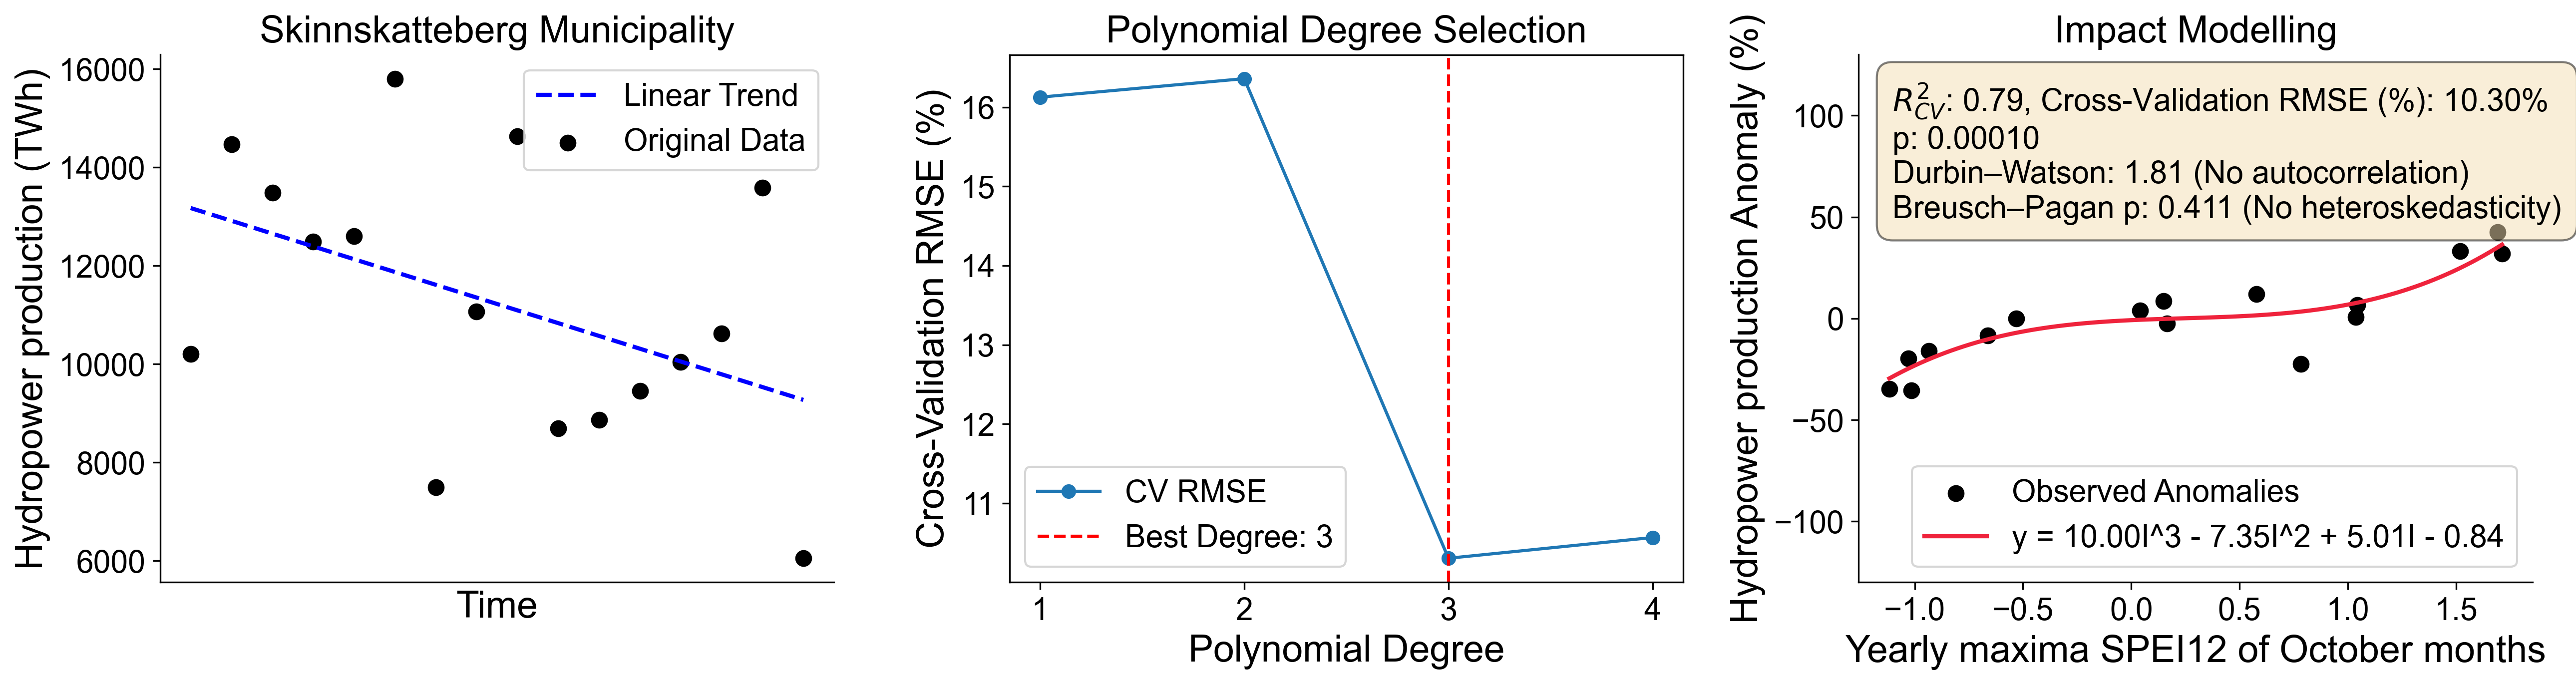

   Count_passed_diag_and_cv Impact variable Hazard variable  Significance %  \
0                        36      hydro_prod          SPEI12           18.27   

   Mean_CV_R2  Median_CV_R2  Threshold   Trend  Aggregation  
0    0.377112      0.373469        NaN  Linear           10  


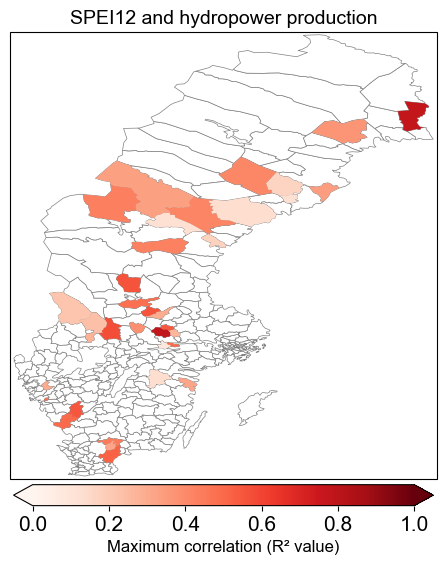

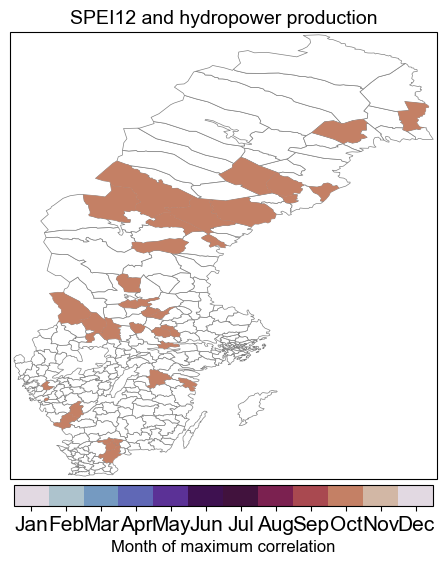

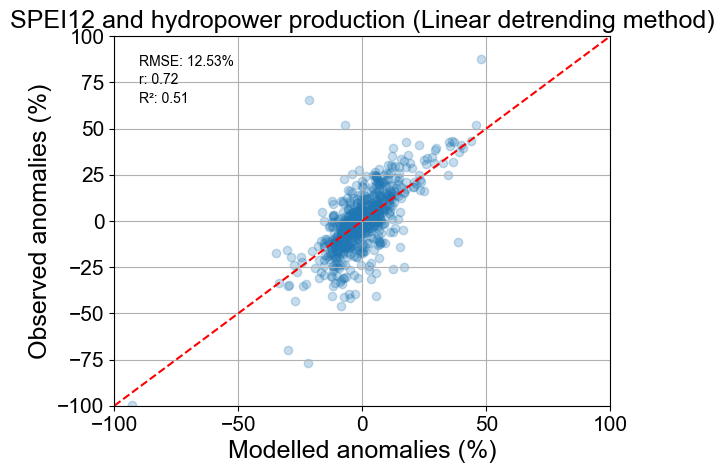

In [33]:
# Example fit
# Check Runs (Drought impacts in hydropower production at different months): 
runs_df=pd.read_excel(r'C:\Users\MarlonVieiraPassos\OneDrive - SEI\Documents\KTH PhD\Thesis Work\Task 2\Data\Variable Runs Municipality.xlsx',
                         'Energy')
runs_df=runs_df.sort_values('hazard_var', ascending=False)
runs_df=runs_df[runs_df['Threshold Type']=='none']
#runs_df=runs_df[runs_df['hazard_var']!='SPEI3']
#runs_df=runs_df[runs_df['hazard_var']=='DFI']
runs_df=runs_df[runs_df['hazard_var']=='SPEI12']
#runs_df=runs_df[runs_df['hazard_var']=='HWI']
#runs_df=runs_df[runs_df['impact_var']=='livestock']
runs_df=runs_df[runs_df['impact_var']=='hydro_prod']
#runs_df=runs_df[runs_df['impact_var']=='crop_yield_total']
all_corr_df=pd.DataFrame()
all_count_df=pd.DataFrame()
all_saved_data=pd.DataFrame()
#trends=['LOWESS']
trends=['Linear']
runs_df['Count']=np.nan
runs_df['Trend']=np.nan
runs_df['Median R2']=np.nan
#runs_df['Aggregation']=1
runs_df['Aggregation']=10
runs_no_trend=runs_df.copy()
for trend in trends:
    runs_df_trend=runs_no_trend.copy()
    runs_df_trend['Trend']=trend
    runs_df = pd.concat([runs_df, runs_df_trend], ignore_index=True)

    
runs_df=runs_df.dropna(subset='Trend')
#months=[2,3,4,5,6,7,8,9,10,11,12]
months=[]
runs_no_month=runs_df.copy()
for month in months:
    runs_df_month=runs_no_month.copy()
    runs_df_month['Aggregation']=month
    runs_df = pd.concat([runs_df, runs_df_month], ignore_index=True)
#runs_df['Mean Change (%)']=np.nan
#runs_df['Mean Loss (%)']=np.nan
window_frac=0.25 # For LOWESS only
for N in range(len(runs_df)):
    trend= runs_df['Trend'].iloc[N]
    var_imp= runs_df['impact_var'].iloc[N]
    var_haz= runs_df['hazard_var'].iloc[N]
    conversion= runs_df['Conversion'].iloc[N]
    threshold= runs_df['Threshold'].iloc[N]
    t_type= runs_df['Threshold Type'].iloc[N]
    #threshold=0
    agg_type= runs_df['Aggregation'].iloc[N]
    data=read_data(agg_type)
    #agg_type= 'mean'
    print('Hazard variable: '+var_haz)
    print('Impact variable: '+var_imp)
    print('Aggregation type: '+str(agg_type))
    print('Threshold type: '+str(t_type))
    print('Trend: '+str(trend))
    print('Threshold: '+str(threshold))
    corr_df, count_df, mean_r2, median_r2, count, saved_data = correlations(data, var_imp, var_haz, threshold, trend, agg_type, impact_info, hazard_info, lower_bounds, upper_bounds)
    runs_df['Mean R2'].iloc[N]=mean_r2
    runs_df['Median R2'].iloc[N]=median_r2
    runs_df['Count'].iloc[N]=count # number of municipality with good results
    all_corr_df = pd.concat([all_corr_df, corr_df], ignore_index=True)
    all_saved_data = pd.concat([all_saved_data, saved_data], ignore_index=True)
    all_count_df = pd.concat([all_count_df, count_df], ignore_index=True)

# Plot graphs of maximum correlations
max_df=pd.DataFrame()
max_df['R2 overall']=np.nan
max_df['RMSE overall']=np.nan
r_squared_list=[]
r_list=[]
p_list=[]
rmse_list=[]
hazvar_list=[]
impvar_list=[]
trend_list=[]
for trend in all_count_df['Trend'].unique():
    for hazvar in all_count_df['Hazard variable'].unique():
        for impvar in all_count_df['Impact variable'].unique():
            hazvar_list.append(hazvar)
            impvar_list.append(impvar)
            trend_list.append(trend)
           # Select all correlations for all municipalities and months by hazard pair and trend type 
            all_corr_df_var=all_corr_df[all_corr_df['Hazard variable']==hazvar]
            all_corr_df_var=all_corr_df_var[all_corr_df_var['Impact variable']==impvar]
            all_corr_df_var=all_corr_df_var[all_corr_df_var['Trend']==trend]
            # Find maximum correlations by month 
            max_corr_agg = all_corr_df_var.groupby(['Municipality','Impact variable', 'Hazard variable', 'Trend']).agg('max').reset_index()
            max_corr_agg = max_corr_agg[max_corr_agg['Correlation_CV_R2']>0]
            # Drop Aggregation Column from max_corr_agg
            max_corr_agg.drop(columns=['Aggregation', 'A', 'B', 'C', 'D', 'p'], inplace=True)
            # Merge max_corr_agg with all_corr_df based on Correlation and Municipality to obtain corresponding Aggregation with maximum correlation
            max_corr_agg = pd.merge(max_corr_agg, all_corr_df, on=['Municipality', 'Impact variable', 'Hazard variable', 'Correlation_CV_R2', 'Trend'], how='left')
            corr_gdf = pd.merge(kommun_shapefile, max_corr_agg, left_on='KnNamn', right_on='Municipality')
            # Next, retrieve yearly impacts based on month with highest correlation 
            max_data= pd.merge(max_corr_agg, all_saved_data, on=['Municipality', 'Impact variable', 'Hazard variable', 'Aggregation', 'Trend'], how='left')
            impvar_name=impact_info[impact_info['var']==impvar]['Variable Name'].values[0]
            hazvar_name=hazard_info[hazard_info['var']==hazvar]['Variable Name'].values[0]
            title= hazvar_name +' and ' + impvar_name.lower()
            plot_map(corr_gdf, 'Correlation_CV_R2', title, 'Maximum correlation (R² value)',
                     lower_bound=0, upper_bound=1, 
                     vcenter=0, cmap_type='Reds', save='no', filename='r2_map_corrs')
            plot_map_months(corr_gdf, 'Aggregation', title, 'Month of maximum correlation',
                     lower_bound=1, upper_bound=13, 
                     vcenter=0, cmap_type='Reds', save='no', filename='r2_map_months')

            # Sample data
            predicted_anomalies = max_data['Predicted anomalies']
            observed_anomalies = max_data['Observed anomalies']
            
            # Step 1: Filter out anomalies that are too large or too low
            predicted_anomalies = np.where((predicted_anomalies > 100) | (predicted_anomalies < -100), np.nan, predicted_anomalies)
            observed_anomalies = np.where((observed_anomalies > 100) | (observed_anomalies < -100), np.nan, observed_anomalies)

            # Step 2: Create a mask for indices where both arrays are non-NaN
            valid_mask = ~np.isnan(predicted_anomalies) & ~np.isnan(observed_anomalies)

            # Step 3: Filter both arrays using the mask
            predicted_anomalies = predicted_anomalies[valid_mask]
            observed_anomalies = observed_anomalies[valid_mask]

            # Calculate mean root square error and R-squared
            r_squared = r2_score(observed_anomalies, predicted_anomalies)
            r_squared_list.append(r_squared)
            r, p_value = pearsonr(observed_anomalies, predicted_anomalies)
            r_list.append(r)
            p_list.append(p_value)
            #print("R-squared:", r_squared)
            mse = mean_squared_error(observed_anomalies, predicted_anomalies)
            rmse = np.sqrt(mse)
            rmse_list.append(rmse)
            # Define limits
            limit = (-100, 100)

            # Plot scatter with transparency
            plt.scatter(predicted_anomalies, observed_anomalies, alpha=0.25)
            plt.xlim(limit)
            plt.ylim(limit)
            plt.xlabel('Modelled anomalies (%)')
            plt.ylabel('Observed anomalies (%)')
            plt.title(title+' ('+trend+' detrending method)')
            # Plot diagonal line
            plt.plot(limit, limit, color='red', linestyle='--')

            # Add text boxes for mean root square error and R-squared
            plt.text(0.05, 0.95, f'RMSE: {rmse:.2f}%', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
            plt.text(0.05, 0.90, f'r: {r:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
            plt.text(0.05, 0.85, f'R²: {r_squared:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
            plt.grid(True)
            plt.show()

# Save results
max_df['Impact variable']=impvar_list
max_df['Hazard variable']=hazvar_list
max_df['Trend']=trend_list
max_df['R2 overall']=r_squared_list
max_df['R overall']=r_list
#max_df['R mean']=np.nanmean(max_data.Correlation)
#max_df['R2 mean']=np.sqrt(np.nanmean(max_data.Correlation))
max_df['RMSE overall']=rmse_list
#max_df['MAE overall']=mae_list
max_df['p overall']=p_list

In [ ]:
# Batch Runs - Food
runs_df=pd.read_excel('Variable Runs Municipality.xlsx',
                         'Food')
runs_df=runs_df.sort_values('hazard_var', ascending=False)
runs_df=runs_df[runs_df['Threshold Type']=='none']
all_corr_df=pd.DataFrame()
all_count_df=pd.DataFrame()
all_saved_data=pd.DataFrame()
trends=['Linear']
runs_df['Count']=np.nan
runs_df['Trend']=np.nan
runs_df['Median R2']=np.nan
runs_df['Aggregation']=1
runs_no_trend=runs_df.copy()
for trend in trends:
    runs_df_trend=runs_no_trend.copy()
    runs_df_trend['Trend']=trend
    runs_df = pd.concat([runs_df, runs_df_trend], ignore_index=True)
runs_df=runs_df.dropna(subset='Trend')
months=[2,3,4,5,6,7,8,9,10,11,12]
runs_no_month=runs_df.copy()
for month in months:
    runs_df_month=runs_no_month.copy()
    runs_df_month['Aggregation']=month
    runs_df = pd.concat([runs_df, runs_df_month], ignore_index=True)
for N in range(len(runs_df)):
    trend= runs_df['Trend'].iloc[N]
    var_imp= runs_df['impact_var'].iloc[N]
    var_haz= runs_df['hazard_var'].iloc[N]
    conversion= runs_df['Conversion'].iloc[N]
    threshold= runs_df['Threshold'].iloc[N]
    t_type= runs_df['Threshold Type'].iloc[N]
    #threshold=0
    agg_type= runs_df['Aggregation'].iloc[N]
    data=read_data(agg_type)
    #agg_type= 'mean'
    print('Hazard variable: '+var_haz)
    print('Impact variable: '+var_imp)
    print('Aggregation type: '+str(agg_type))
    print('Threshold type: '+str(t_type))
    print('Trend: '+str(trend))
    print('Threshold: '+str(threshold))
    corr_df, count_df, mean_r2, median_r2, count, saved_data = correlations(data, var_imp, var_haz, threshold, trend, agg_type, impact_info, hazard_info, lower_bounds, upper_bounds)
    runs_df['Mean R2'].iloc[N]=mean_r2
    runs_df['Median R2'].iloc[N]=median_r2
    runs_df['Count'].iloc[N]=count # number of municipality with statistically significant results
    all_corr_df = pd.concat([all_corr_df, corr_df], ignore_index=True)
    all_saved_data = pd.concat([all_saved_data, saved_data], ignore_index=True)
    all_count_df = pd.concat([all_count_df, count_df], ignore_index=True)
runs_df.to_excel('Runs_food_municipalities_months.xlsx')
all_saved_data.to_csv('Results_food_municipalities_months.csv')
all_corr_df.to_excel('All_correlations_food_municipalities_months.xlsx')
# Plot graphs of maximum correlations
max_df=pd.DataFrame()
max_df['R2 overall']=np.nan
max_df['RMSE overall']=np.nan
r_squared_list=[]
r_list=[]
p_list=[]
rmse_list=[]
hazvar_list=[]
impvar_list=[]
trend_list=[]
for trend in all_count_df['Trend'].unique():
    for hazvar in all_count_df['Hazard variable'].unique():
        for impvar in all_count_df['Impact variable'].unique():
            hazvar_list.append(hazvar)
            impvar_list.append(impvar)
            trend_list.append(trend)
           # Select all correlations for all municipalities and months by hazard pair and trend type 
            all_corr_df_var=all_corr_df[all_corr_df['Hazard variable']==hazvar]
            all_corr_df_var=all_corr_df_var[all_corr_df_var['Impact variable']==impvar]
            all_corr_df_var=all_corr_df_var[all_corr_df_var['Trend']==trend]
            # Find maximum correlations by month 
            max_corr_agg = all_corr_df_var.groupby(['Municipality','Impact variable', 'Hazard variable', 'Trend']).agg('max').reset_index()
            max_corr_agg = max_corr_agg[max_corr_agg['Correlation_CV_R2']>0]
            # Drop Aggregation Column from max_corr_agg
            max_corr_agg.drop(columns=['Aggregation', 'A', 'B', 'C', 'D', 'E', 'p'], inplace=True)
            # Merge max_corr_agg with all_corr_df based on Correlation and Municipality to obtain corresponding Aggregation with maximum correlation
            max_corr_agg = pd.merge(max_corr_agg, all_corr_df, on=['Municipality', 'Impact variable', 'Hazard variable', 'Correlation_CV_R2', 'Trend'], how='left')
            corr_gdf = pd.merge(kommun_shapefile, max_corr_agg, left_on='KnNamn', right_on='Municipality')
            # Next, retrieve yearly impacts based on month with highest correlation 
            max_data= pd.merge(max_corr_agg, all_saved_data, on=['Municipality', 'Impact variable', 'Hazard variable', 'Aggregation', 'Trend'], how='left')
            impvar_name=impact_info[impact_info['var']==impvar]['Variable Name'].values[0]
            hazvar_name=hazard_info[hazard_info['var']==hazvar]['Variable Name'].values[0]
            title= hazvar_name +' and ' + impvar_name.lower()
            plot_map(corr_gdf, 'Correlation_CV_R2', title, 'Maximum correlation (R² value)',
                     lower_bound=0, upper_bound=1, 
                     vcenter=0, cmap_type='Reds', save='no', filename='r2_map_corrs')
            plot_map_months(corr_gdf, 'Aggregation', title, 'Month of maximum correlation',
                     lower_bound=1, upper_bound=13, 
                     vcenter=0, cmap_type='Reds', save='no', filename='r2_map_months')

            # Sample data
            predicted_anomalies = max_data['Predicted anomalies']
            observed_anomalies = max_data['Observed anomalies']
            
            # Step 1: Filter out anomalies that are too large or too low
            predicted_anomalies = np.where((predicted_anomalies > 100) | (predicted_anomalies < -100), np.nan, predicted_anomalies)
            observed_anomalies = np.where((observed_anomalies > 100) | (observed_anomalies < -100), np.nan, observed_anomalies)

            # Step 2: Create a mask for indices where both arrays are non-NaN
            valid_mask = ~np.isnan(predicted_anomalies) & ~np.isnan(observed_anomalies)

            # Step 3: Filter both arrays using the mask
            predicted_anomalies = predicted_anomalies[valid_mask]
            observed_anomalies = observed_anomalies[valid_mask]

            # Calculate mean root square error and R-squared
            r_squared = r2_score(observed_anomalies, predicted_anomalies)
            r_squared_list.append(r_squared)
            r, p_value = pearsonr(observed_anomalies, predicted_anomalies)
            r_list.append(r)
            p_list.append(p_value)
            #print("R-squared:", r_squared)
            mse = mean_squared_error(observed_anomalies, predicted_anomalies)
            rmse = np.sqrt(mse)
            rmse_list.append(rmse)
            # Define limits
            limit = (-100, 100)

            # Plot scatter with transparency
            plt.scatter(predicted_anomalies, observed_anomalies, alpha=0.25)
            plt.xlim(limit)
            plt.ylim(limit)
            plt.xlabel('Modelled anomalies (%)')
            plt.ylabel('Observed anomalies (%)')
            plt.title(title+' ('+trend+' detrending method)')
            # Plot diagonal line
            plt.plot(limit, limit, color='red', linestyle='--')

            # Add text boxes for mean root square error and R-squared
            plt.text(0.05, 0.95, f'RMSE: {rmse:.2f}%', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
            plt.text(0.05, 0.90, f'r: {r:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
            plt.text(0.05, 0.85, f'R²: {r_squared:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
            plt.grid(True)
            plt.show()

# Save results
max_df['Impact variable']=impvar_list
max_df['Hazard variable']=hazvar_list
max_df['Trend']=trend_list
max_df['R2 overall']=r_squared_list
max_df['R overall']=r_list
max_df['RMSE overall']=rmse_list
max_df['p overall']=p_list
max_df.to_excel('Correlations_food_municipalities_months.xlsx')

In [ ]:
# Batch Runs - Water
runs_df=pd.read_excel('Variable Runs Municipality.xlsx','Water')
runs_df=runs_df.sort_values('hazard_var', ascending=False)
runs_df=runs_df[runs_df['Threshold Type']=='none']
all_corr_df=pd.DataFrame()
all_count_df=pd.DataFrame()
all_saved_data=pd.DataFrame()
trends=['Linear']
runs_df['Count']=np.nan
runs_df['Trend']=np.nan
runs_df['Median R2']=np.nan
runs_df['Aggregation']=1
runs_no_trend=runs_df.copy()
for trend in trends:
    runs_df_trend=runs_no_trend.copy()
    runs_df_trend['Trend']=trend
    runs_df = pd.concat([runs_df, runs_df_trend], ignore_index=True)
runs_df=runs_df.dropna(subset='Trend')
months=[2,3,4,5,6,7,8,9,10,11,12]
runs_no_month=runs_df.copy()
for month in months:
    runs_df_month=runs_no_month.copy()
    runs_df_month['Aggregation']=month
    runs_df = pd.concat([runs_df, runs_df_month], ignore_index=True)
for N in range(len(runs_df)):
    trend= runs_df['Trend'].iloc[N]
    var_imp= runs_df['impact_var'].iloc[N]
    var_haz= runs_df['hazard_var'].iloc[N]
    conversion= runs_df['Conversion'].iloc[N]
    threshold= runs_df['Threshold'].iloc[N]
    t_type= runs_df['Threshold Type'].iloc[N]
    #threshold=0
    agg_type= runs_df['Aggregation'].iloc[N]
    data=read_data(agg_type)
    #agg_type= 'mean'
    print('Hazard variable: '+var_haz)
    print('Impact variable: '+var_imp)
    print('Aggregation type: '+str(agg_type))
    print('Threshold type: '+str(t_type))
    print('Trend: '+str(trend))
    print('Threshold: '+str(threshold))
    corr_df, count_df, mean_r2, median_r2, count, saved_data = correlations(data, var_imp, var_haz, threshold, trend, agg_type, impact_info, hazard_info, lower_bounds, upper_bounds)
    runs_df['Mean R2'].iloc[N]=mean_r2
    runs_df['Median R2'].iloc[N]=median_r2
    runs_df['Count'].iloc[N]=count # number of municipality with statistically significant results
    all_corr_df = pd.concat([all_corr_df, corr_df], ignore_index=True)
    all_saved_data = pd.concat([all_saved_data, saved_data], ignore_index=True)
    all_count_df = pd.concat([all_count_df, count_df], ignore_index=True)
runs_df.to_excel('Runs_water_municipalities_months.xlsx')
all_saved_data.to_csv('Results_water_municipalities_months.csv')
all_corr_df.to_excel('All_correlations_water_municipalities_months.xlsx')
# Plot graphs of maximum correlations
max_df=pd.DataFrame()
max_df['R2 overall']=np.nan
max_df['RMSE overall']=np.nan
r_squared_list=[]
r_list=[]
p_list=[]
rmse_list=[]
hazvar_list=[]
impvar_list=[]
trend_list=[]
for trend in all_count_df['Trend'].unique():
    for hazvar in all_count_df['Hazard variable'].unique():
        for impvar in all_count_df['Impact variable'].unique():
            hazvar_list.append(hazvar)
            impvar_list.append(impvar)
            trend_list.append(trend)
           # Select all correlations for all municipalities and months by hazard pair and trend type 
            all_corr_df_var=all_corr_df[all_corr_df['Hazard variable']==hazvar]
            all_corr_df_var=all_corr_df_var[all_corr_df_var['Impact variable']==impvar]
            all_corr_df_var=all_corr_df_var[all_corr_df_var['Trend']==trend]
            # Find maximum correlations by month 
            max_corr_agg = all_corr_df_var.groupby(['Municipality','Impact variable', 'Hazard variable', 'Trend']).agg('max').reset_index()
            max_corr_agg = max_corr_agg[max_corr_agg['Correlation_CV_R2']>0]
            # Drop Aggregation Column from max_corr_agg
            max_corr_agg.drop(columns=['Aggregation', 'A', 'B', 'C', 'D', 'p'], inplace=True)
            # Merge max_corr_agg with all_corr_df based on Correlation and Municipality to obtain corresponding Aggregation with maximum correlation
            max_corr_agg = pd.merge(max_corr_agg, all_corr_df, on=['Municipality', 'Impact variable', 'Hazard variable', 'Correlation_CV_R2', 'Trend'], how='left')
            corr_gdf = pd.merge(kommun_shapefile, max_corr_agg, left_on='KnNamn', right_on='Municipality')
            # Next, retrieve yearly impacts based on month with highest correlation 
            max_data= pd.merge(max_corr_agg, all_saved_data, on=['Municipality', 'Impact variable', 'Hazard variable', 'Aggregation', 'Trend'], how='left')
            impvar_name=impact_info[impact_info['var']==impvar]['Variable Name'].values[0]
            hazvar_name=hazard_info[hazard_info['var']==hazvar]['Variable Name'].values[0]
            title= hazvar_name +' and ' + impvar_name.lower()
            plot_map(corr_gdf, 'Correlation_CV_R2', title, 'Maximum correlation (R² value)',
                     lower_bound=0, upper_bound=1, 
                     vcenter=0, cmap_type='Reds', save='no', filename='r2_map_corrs')
            plot_map_months(corr_gdf, 'Aggregation', title, 'Month of maximum correlation',
                     lower_bound=1, upper_bound=13, 
                     vcenter=0, cmap_type='Reds', save='no', filename='r2_map_months')

            # Sample data
            predicted_anomalies = max_data['Predicted anomalies']
            observed_anomalies = max_data['Observed anomalies']
            
            # Step 1: Filter out anomalies that are too large or too low
            predicted_anomalies = np.where((predicted_anomalies > 100) | (predicted_anomalies < -100), np.nan, predicted_anomalies)
            observed_anomalies = np.where((observed_anomalies > 100) | (observed_anomalies < -100), np.nan, observed_anomalies)

            # Step 2: Create a mask for indices where both arrays are non-NaN
            valid_mask = ~np.isnan(predicted_anomalies) & ~np.isnan(observed_anomalies)

            # Step 3: Filter both arrays using the mask
            predicted_anomalies = predicted_anomalies[valid_mask]
            observed_anomalies = observed_anomalies[valid_mask]

            # Calculate mean root square error and R-squared
            r_squared = r2_score(observed_anomalies, predicted_anomalies)
            r_squared_list.append(r_squared)
            r, p_value = pearsonr(observed_anomalies, predicted_anomalies)
            r_list.append(r)
            p_list.append(p_value)
            #print("R-squared:", r_squared)
            mse = mean_squared_error(observed_anomalies, predicted_anomalies)
            rmse = np.sqrt(mse)
            rmse_list.append(rmse)
            # Define limits
            limit = (-100, 100)

            # Plot scatter with transparency
            plt.scatter(predicted_anomalies, observed_anomalies, alpha=0.25)
            plt.xlim(limit)
            plt.ylim(limit)
            plt.xlabel('Modelled anomalies (%)')
            plt.ylabel('Observed anomalies (%)')
            plt.title(title+' ('+trend+' detrending method)')
            # Plot diagonal line
            plt.plot(limit, limit, color='red', linestyle='--')

            # Add text boxes for mean root square error and R-squared
            plt.text(0.05, 0.95, f'RMSE: {rmse:.2f}%', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
            plt.text(0.05, 0.90, f'r: {r:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
            plt.text(0.05, 0.85, f'R²: {r_squared:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
            plt.grid(True)
            plt.show()

# Save results
max_df['Impact variable']=impvar_list
max_df['Hazard variable']=hazvar_list
max_df['Trend']=trend_list
max_df['R2 overall']=r_squared_list
max_df['R overall']=r_list
max_df['RMSE overall']=rmse_list
max_df['p overall']=p_list
max_df.to_excel('Correlations_water_municipalities_months.xlsx')

In [ ]:
max_corr_agg

In [ ]:
# Batch Runs - Energy
runs_df=pd.read_excel('Variable Runs Municipality.xlsx',
                         'Energy')
runs_df=runs_df.sort_values('hazard_var', ascending=False)
runs_df=runs_df[runs_df['Threshold Type']=='none']
all_corr_df=pd.DataFrame()
all_count_df=pd.DataFrame()
all_saved_data=pd.DataFrame()
trends=['Linear']
runs_df['Count']=np.nan
runs_df['Trend']=np.nan
runs_df['Median R2']=np.nan
runs_df['Aggregation']=1
runs_no_trend=runs_df.copy()
for trend in trends:
    runs_df_trend=runs_no_trend.copy()
    runs_df_trend['Trend']=trend
    runs_df = pd.concat([runs_df, runs_df_trend], ignore_index=True)
runs_df=runs_df.dropna(subset='Trend')
months=[2,3,4,5,6,7,8,9,10,11,12]
runs_no_month=runs_df.copy()
for month in months:
    runs_df_month=runs_no_month.copy()
    runs_df_month['Aggregation']=month
    runs_df = pd.concat([runs_df, runs_df_month], ignore_index=True)
window_frac=0.25 # For LOWESS only
for N in range(len(runs_df)):
    trend= runs_df['Trend'].iloc[N]
    var_imp= runs_df['impact_var'].iloc[N]
    var_haz= runs_df['hazard_var'].iloc[N]
    conversion= runs_df['Conversion'].iloc[N]
    threshold= runs_df['Threshold'].iloc[N]
    t_type= runs_df['Threshold Type'].iloc[N]
    #threshold=0
    agg_type= runs_df['Aggregation'].iloc[N]
    data=read_data(agg_type)
    #agg_type= 'mean'
    print('Hazard variable: '+var_haz)
    print('Impact variable: '+var_imp)
    print('Aggregation type: '+str(agg_type))
    print('Threshold type: '+str(t_type))
    print('Trend: '+str(trend))
    print('Threshold: '+str(threshold))
    corr_df, count_df, mean_r2, median_r2, count, saved_data = correlations(data, var_imp, var_haz, threshold, trend, agg_type, impact_info, hazard_info, lower_bounds, upper_bounds)
    runs_df['Mean R2'].iloc[N]=mean_r2
    runs_df['Median R2'].iloc[N]=median_r2
    runs_df['Count'].iloc[N]=count # number of municipality with good results
    all_corr_df = pd.concat([all_corr_df, corr_df], ignore_index=True)
    all_saved_data = pd.concat([all_saved_data, saved_data], ignore_index=True)
    all_count_df = pd.concat([all_count_df, count_df], ignore_index=True)
runs_df.to_excel('Runs_energy_municipalities_months.xlsx')
all_saved_data.to_csv('Results_energy_municipalities_months.csv')
all_corr_df.to_excel('All_correlations_energy_municipalities_months.xlsx')
# Plot graphs of maximum correlations
max_df=pd.DataFrame()
max_df['R2 overall']=np.nan
max_df['RMSE overall']=np.nan
r_squared_list=[]
r_list=[]
p_list=[]
rmse_list=[]
hazvar_list=[]
impvar_list=[]
trend_list=[]
for trend in all_count_df['Trend'].unique():
    for hazvar in all_count_df['Hazard variable'].unique():
        for impvar in all_count_df['Impact variable'].unique():
            hazvar_list.append(hazvar)
            impvar_list.append(impvar)
            trend_list.append(trend)
           # Select all correlations for all municipalities and months by hazard pair and trend type 
            all_corr_df_var=all_corr_df[all_corr_df['Hazard variable']==hazvar]
            all_corr_df_var=all_corr_df_var[all_corr_df_var['Impact variable']==impvar]
            all_corr_df_var=all_corr_df_var[all_corr_df_var['Trend']==trend]
            # Find maximum correlations by month 
            max_corr_agg = all_corr_df_var.groupby(['Municipality','Impact variable', 'Hazard variable', 'Trend']).agg('max').reset_index()
            max_corr_agg = max_corr_agg[max_corr_agg['Correlation_CV_R2']>0]
            # Drop Aggregation Column from max_corr_agg
            max_corr_agg.drop(columns=['Aggregation', 'A', 'B', 'C', 'D', 'p'], inplace=True)
            # Merge max_corr_agg with all_corr_df based on Correlation and Municipality to obtain corresponding Aggregation with maximum correlation
            max_corr_agg = pd.merge(max_corr_agg, all_corr_df, on=['Municipality', 'Impact variable', 'Hazard variable', 'Correlation_CV_R2', 'Trend'], how='left')
            corr_gdf = pd.merge(kommun_shapefile, max_corr_agg, left_on='KnNamn', right_on='Municipality')
            # Next, retrieve yearly impacts based on month with highest correlation 
            max_data= pd.merge(max_corr_agg, all_saved_data, on=['Municipality', 'Impact variable', 'Hazard variable', 'Aggregation', 'Trend'], how='left')
            impvar_name=impact_info[impact_info['var']==impvar]['Variable Name'].values[0]
            hazvar_name=hazard_info[hazard_info['var']==hazvar]['Variable Name'].values[0]
            title= hazvar_name +' and ' + impvar_name.lower()
            plot_map(corr_gdf, 'Correlation_CV_R2', title, 'Maximum correlation (R² value)',
                     lower_bound=0, upper_bound=1, 
                     vcenter=0, cmap_type='Reds', save='no', filename='r2_map_corrs')
            plot_map_months(corr_gdf, 'Aggregation', title, 'Month of maximum correlation',
                     lower_bound=1, upper_bound=13, 
                     vcenter=0, cmap_type='Reds', save='no', filename='r2_map_months')

            # Sample data
            predicted_anomalies = max_data['Predicted anomalies']
            observed_anomalies = max_data['Observed anomalies']
            
            # Step 1: Filter out anomalies that are too large or too low
            predicted_anomalies = np.where((predicted_anomalies > 100) | (predicted_anomalies < -100), np.nan, predicted_anomalies)
            observed_anomalies = np.where((observed_anomalies > 100) | (observed_anomalies < -100), np.nan, observed_anomalies)

            # Step 2: Create a mask for indices where both arrays are non-NaN
            valid_mask = ~np.isnan(predicted_anomalies) & ~np.isnan(observed_anomalies)

            # Step 3: Filter both arrays using the mask
            predicted_anomalies = predicted_anomalies[valid_mask]
            observed_anomalies = observed_anomalies[valid_mask]

            # Calculate mean root square error and R-squared
            r_squared = r2_score(observed_anomalies, predicted_anomalies)
            r_squared_list.append(r_squared)
            r, p_value = pearsonr(observed_anomalies, predicted_anomalies)
            r_list.append(r)
            p_list.append(p_value)
            #print("R-squared:", r_squared)
            mse = mean_squared_error(observed_anomalies, predicted_anomalies)
            rmse = np.sqrt(mse)
            rmse_list.append(rmse)
            # Define limits
            limit = (-100, 100)

            # Plot scatter with transparency
            plt.scatter(predicted_anomalies, observed_anomalies, alpha=0.25)
            plt.xlim(limit)
            plt.ylim(limit)
            plt.xlabel('Modelled anomalies (%)')
            plt.ylabel('Observed anomalies (%)')
            plt.title(title+' ('+trend+' detrending method)')
            # Plot diagonal line
            plt.plot(limit, limit, color='red', linestyle='--')

            # Add text boxes for mean root square error and R-squared
            plt.text(0.05, 0.95, f'RMSE: {rmse:.2f}%', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
            plt.text(0.05, 0.90, f'r: {r:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
            plt.text(0.05, 0.85, f'R²: {r_squared:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
            plt.grid(True)
            plt.show()

# Save results
max_df['Impact variable']=impvar_list
max_df['Hazard variable']=hazvar_list
max_df['Trend']=trend_list
max_df['R2 overall']=r_squared_list
max_df['R overall']=r_list
max_df['RMSE overall']=rmse_list
max_df['p overall']=p_list
max_df.to_excel('Correlations_energy_municipalities_months.xlsx')

In [ ]:
# Merge all results for plotting
import pandas as pd
import pandas as pd

# Load correlation data and concatenate
all_corr_df = pd.read_excel('All_correlations_energy_municipalities_months.xlsx')
all_corr_df = pd.concat([
    all_corr_df,
    pd.read_excel('All_correlations_water_municipalities_months.xlsx'),
    pd.read_excel('All_correlations_food_municipalities_months.xlsx')
], ignore_index=True)

# Load results data and concatenate
all_saved_data = pd.read_csv('Results_energy_municipalities_months.csv')
all_saved_data = pd.concat([
    all_saved_data,
    pd.read_csv('Results_water_municipalities_months.csv'),
    pd.read_csv('Results_food_municipalities_months.csv')
], ignore_index=True)

# Drop 'Unnamed: 0' columns
all_corr_df = all_corr_df.drop(columns=['Unnamed: 0'])
all_saved_data = all_saved_data.drop(columns=['Unnamed: 0'])

# Load impact and hazard info
impact_info = pd.read_excel('Variable List.xlsx', sheet_name='Impact')
hazard_info = pd.read_excel('Variable List.xlsx', sheet_name='Hazard')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
plt.rcdefaults()
def plot_associations(all_corr_df, impact_info, hazard_info, all_saved_data):
    fig, axes = plt.subplots(3, 3, figsize=(12, 10), dpi=300)
    axes = axes.flatten()  # Flatten the 2D array of axes for easier iteration

    # Set font properties for publication quality
    SIZE_DEFAULT = 14
    SIZE_LARGE = 14
    plt.rc("font", family="Arial")
    #plt.rc('font', serif='Helvetica Neue') 
    plt.rc("font", size=SIZE_DEFAULT)
    plt.rc("axes", titlesize=SIZE_LARGE)
    plt.rc("axes", labelsize=SIZE_LARGE)
    plt.rc("xtick", labelsize=SIZE_DEFAULT)
    plt.rc("ytick", labelsize=SIZE_DEFAULT)

    # Define a color palette
    colors = ["#2B2F42", "#EF233C", "#8D99AE"]

    # Initialize lists to store results
    r_squared_list = []

    rmse_list = []
    hazvar_list = []
    impvar_list = []
    trend_list = []

    # Detrending method
    trends = ['Linear']

    # Counter for subplot index
    plot_index = 0
    impvars = all_corr_df['Impact variable'].unique()
    impvars = impvars[impvars != 'groundwater']
    impvars = impvars[impvars != 'livestock']
    hazvars = all_corr_df['Hazard variable'].unique()

    for trend in trends:
        for hazvar in hazvars:
            for impvar in impvars:
                hazvar_list.append(hazvar)
                impvar_list.append(impvar)
                trend_list.append(trend)

                # Filter data for the specific hazard-impact pair and trend
                all_corr_df_var = all_corr_df[(all_corr_df['Hazard variable'] == hazvar) & 
                                              (all_corr_df['Impact variable'] == impvar) & 
                                              (all_corr_df['Trend'] == trend)]

                # Find maximum correlations by month
                max_corr_agg = all_corr_df_var.groupby(['Municipality', 'Impact variable', 'Hazard variable', 'Trend']).agg('max').reset_index()
                max_corr_agg = max_corr_agg[max_corr_agg['Correlation_CV_R2'] > 0]
                max_corr_agg = max_corr_agg.drop(columns=['Aggregation', 'A', 'B', 'C', 'D', 'E', 'ATE'], errors='ignore')
                max_corr_agg = pd.merge(max_corr_agg, all_corr_df, on=['Municipality', 'Impact variable', 'Hazard variable', 'Correlation_CV_R2', 'Trend'], how='left')

                corr_gdf = pd.merge(kommun_shapefile, max_corr_agg, left_on='KnNamn', right_on='Municipality')

                impvar_name = impact_info[impact_info['var'] == impvar]['Variable Name'].values[0]
                hazvar_name = hazard_info[hazard_info['var'] == hazvar]['Variable Name'].values[0]
                title = f'{hazvar_name} and {impvar_name.lower()}'

                # Retrieve data
                max_data = pd.merge(max_corr_agg, all_saved_data, on=['Municipality', 'Impact variable', 'Hazard variable', 'Aggregation', 'Trend'], how='left')
                predicted_anomalies = max_data['Predicted anomalies']
                observed_anomalies = max_data['Observed anomalies']

                # Filter anomalies
                predicted_anomalies = np.where((predicted_anomalies > 100) | (predicted_anomalies < -100), np.nan, predicted_anomalies)
                observed_anomalies = np.where((observed_anomalies > 100) | (observed_anomalies < -100), np.nan, observed_anomalies)

                # Create mask for valid data
                valid_mask = ~np.isnan(predicted_anomalies) & ~np.isnan(observed_anomalies)
                predicted_anomalies = predicted_anomalies[valid_mask]
                observed_anomalies = observed_anomalies[valid_mask]

                # Calculate RMSE and R-squared
                r_squared = r2_score(observed_anomalies, predicted_anomalies)
                #r, p_value = pearsonr(observed_anomalies, predicted_anomalies) # not suitable for nonlinear regression
                rmse = np.sqrt(mean_squared_error(observed_anomalies, predicted_anomalies))
                std = np.std(observed_anomalies)

                r_squared_list.append(r_squared)
                rmse_list.append(rmse)

                # Define plot limits
                limit = (-100, 100)

                # Plot scatter with transparency
                ax = axes[plot_index]
                ax.scatter(predicted_anomalies, observed_anomalies, alpha=0.05, color=colors[0])
                ax.plot(limit, limit, color=colors[1], linestyle='--', linewidth=1.5)

                # Set axis labels and title
                ax.set_xlim(limit)
                ax.set_ylim(limit)
                ax.set_xlabel('Estimated anomalies (%)', fontsize=SIZE_LARGE)
                ax.set_ylabel('Observed anomalies (%)', fontsize=SIZE_LARGE)
                ax.tick_params(axis='both', which='major', labelsize=SIZE_DEFAULT)
                ax.set_title(title)

                # Add text box for statistics
                ax.text(0.05, 0.95, f'R²: {r_squared:.2f}', transform=ax.transAxes, fontsize=SIZE_DEFAULT, verticalalignment='top')
                #ax.text(0.05, 0.85, f'r: {r:.2f}', transform=ax.transAxes, fontsize=SIZE_DEFAULT, verticalalignment='top')
                ax.text(0.05, 0.85, f'RMSE: {rmse:.2f}%', transform=ax.transAxes, fontsize=SIZE_DEFAULT, verticalalignment='top')
                ax.text(0.05, 0.75, f'$\sigma$: {std:.2f}%', transform=ax.transAxes, fontsize=SIZE_DEFAULT, verticalalignment='top')

                # Remove gridlines
                ax.grid(False)

                # Move to the next subplot
                plot_index += 1

    # Adjust layout and save figure
    plt.tight_layout()
    plt.savefig('fig_models.svg', dpi=300, bbox_inches='tight')
    plt.savefig('fig_models.pdf', dpi=300, bbox_inches='tight')
    plt.show()

plot_associations(all_corr_df, impact_info, hazard_info, all_saved_data)
